<div style="padding:10px; 
            color:black;
            margin:10px;
            font-size:150%;
            display:fill;
            border-radius:1px;
            border-style: solid;
            border-color:black;
            background-color:gold;
            overflow:hidden;">
    <center>
        <a id='top'></a>
        <b style="color:black">Not my code.... Table of Contents</b>
    </center>
    <br>
    <ul>
        <li>
            <a href="#1" style="color:black">1 - Imports</a>
        </li>
        <li>
            <a href="#2" style="color:black">2 - Data Preprocessing</a>
            <ul>
                <li>
                    <a href="#2-1" style="color:black">2.1 - Create Directories</a>
                </li>
                <li>
                    <a href="#2-2" style="color:black">2.2 - Creating Generators</a>
                </li>
            </ul>
        </li>
        <li>
            <a href="#3" style="color:black">3 - Model Implementation</a>
        </li>
        <li>
            <a href="#4" style="color:black">4 - Evaluation</a>
            <ul>
                <li>
                    <a href="#4-1" style="color:black">4.1 - Evaluation on Test Set</a>
                </li>
                <li>
                    <a href="#4-2" style="color:black">4.2 - Visualizing  Predictions</a>
                </li>
                <li>
<a href="#4-3" style="color:black">4.3 - Visualizing Activation Maps</a>
</li>
<li>
<a href="#4-4" style="color:black">4.4 - Visualizing Training Process</a>
</li>
</ul>
</li>
<li>
<a href="#5" style="color:black">5 - Trying Data Augmentation</a>
</li>
<li>
<a href="#6" style="color:black">6 - Conclusion</a>
</li>
<li>
<a href="#7" style="color:black">7 - Thank You</a>
</li>
</ul>

</div>


<a id="1"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Imports</center></h1>




# Imports

In [71]:
#!pip install anylabeling

In [72]:
!pip install plotly -q

In [73]:
!pip install tensorflow keras --upgrade -q

In [128]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import scipy as sp
import itertools

from scipy import ndimage
from shutil import copyfile, rmtree
import tensorflow as tf
from tensorflow.keras.layers import Conv2D,Add,MaxPooling2D, Dense, BatchNormalization,Input, Dropout, AveragePooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator 


In [129]:
!pip install kagglehub -q

In [130]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/arulipn/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1


<a id="2"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Data Preprocessing</center></h1>
    
# Data Preprocessing


**Let's check the distribution of the data**

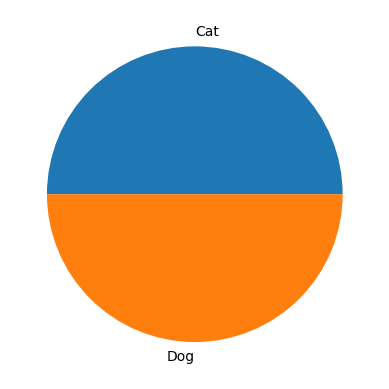

In [131]:
class_names = ['Cat', 'Dog'] 

n_dogs = len(os.listdir('/home/arulipn/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Dog'))
n_cats = len(os.listdir('/home/arulipn/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Cat'))
n_images = [n_cats, n_dogs]
plt.pie(n_images, labels = class_names)
plt.show() 

<a name="2-1"></a>
## create directories for training and validation

In [132]:
base = "/tmp/cats-v-dogs"

# Ištrina, jei egzistuoja
shutil.rmtree(base, ignore_errors=True)

In [133]:
try:
    os.mkdir('/tmp/cats-v-dogs')
    os.mkdir('/tmp/cats-v-dogs/training')
    os.mkdir('/tmp/cats-v-dogs/validation')
    os.mkdir('/tmp/cats-v-dogs/test')
    os.mkdir('/tmp/cats-v-dogs/training/cats')
    os.mkdir('/tmp/cats-v-dogs/training/dogs')
    os.mkdir('/tmp/cats-v-dogs/validation/cats')
    os.mkdir('/tmp/cats-v-dogs/validation/dogs')
    os.mkdir('/tmp/cats-v-dogs/test/cats')
    os.mkdir('/tmp/cats-v-dogs/test/dogs')
except OSError:
    print('Error failed to make directory')

In [134]:
#Define data path
CAT_DIR = '/home/arulipn/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Cat'
DOG_DIR = '/home/arulipn/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1/PetImages/Dog'

TRAINING_DIR = "/tmp/cats-v-dogs/training/"
VALIDATION_DIR = "/tmp/cats-v-dogs/validation/"

TRAINING_CATS = os.path.join(TRAINING_DIR, "cats/")
VALIDATION_CATS = os.path.join(VALIDATION_DIR, "cats/")

TRAINING_DOGS = os.path.join(TRAINING_DIR, "dogs/")
VALIDATION_DOGS = os.path.join(VALIDATION_DIR, "dogs/")

# Define whether to include test split or not
INCLUDE_TEST = True

In [135]:
print(len(os.listdir('/tmp/cats-v-dogs/training/cats')))
print(len(os.listdir('/tmp/cats-v-dogs/training/dogs')))

print(len(os.listdir('/tmp/cats-v-dogs/validation/cats')))
print(len(os.listdir('/tmp/cats-v-dogs/validation/dogs')))

print(len(os.listdir('/tmp/cats-v-dogs/test/cats')))
print(len(os.listdir('/tmp/cats-v-dogs/test/dogs')))

0
0
0
0
0
0


**Now let's create  a function to split the   data**

In [136]:
def split_data(main_dir, training_dir, validation_dir, test_dir=None, include_test_split = True,  split_size=0.9):
    """
    Splits the data into train validation and test sets (optional)

    Args:
    main_dir (string):  path containing the images
    training_dir (string):  path to be used for training
    validation_dir (string):  path to be used for validation
    test_dir (string):  path to be used for test
    include_test_split (boolen):  whether to include a test split or not
    split_size (float): size of the dataset to be used for training
    """
    files = []
    for file in os.listdir(main_dir):
        if  os.path.getsize(os.path.join(main_dir, file)): # check if the file's size isn't 0
            files.append(file) # appends file name to a list

    shuffled_files = random.sample(files,  len(files)) # shuffles the data
    split = int(0.9 * len(shuffled_files)) #the training split casted into int for numeric rounding
    train = shuffled_files[:split] #training split
    split_valid_test = int(split + (len(shuffled_files)-split)/2)
   
    if include_test_split:
        validation = shuffled_files[split:split_valid_test] # validation split
        test = shuffled_files[split_valid_test:]
    else:
        validation = shuffled_files[split:]

    for element in train:
        copyfile(os.path.join(main_dir,  element), os.path.join(training_dir, element)) # copy files into training directory

    for element in validation:
        copyfile(os.path.join(main_dir,  element), os.path.join(validation_dir, element))# copy files into validation directory
        
    if include_test_split:
        for element in test:
            copyfile(os.path.join(main_dir,  element), os.path.join(test_dir, element)) # copy files into test directory
    print("Split sucessful!")

**Now let's call the function to create the  training/validation data**

In [137]:
split_data(CAT_DIR, '/tmp/cats-v-dogs/training/cats', '/tmp/cats-v-dogs/validation/cats', '/tmp/cats-v-dogs/test/cats',INCLUDE_TEST, 0.9)
split_data(DOG_DIR, '/tmp/cats-v-dogs/training/dogs', '/tmp/cats-v-dogs/validation/dogs','/tmp/cats-v-dogs/test/dogs',INCLUDE_TEST, 0.9)

Split sucessful!
Split sucessful!


**As a sanity check let's check the data directories**

In [138]:
print(len(os.listdir('/tmp/cats-v-dogs/training/cats')))
print(len(os.listdir('/tmp/cats-v-dogs/training/dogs')))

print(len(os.listdir('/tmp/cats-v-dogs/validation/cats')))
print(len(os.listdir('/tmp/cats-v-dogs/validation/dogs')))


print(len(os.listdir('/tmp/cats-v-dogs/test/cats')))
print(len(os.listdir('/tmp/cats-v-dogs/test/dogs')))

11250
11250
625
625
625
625


<a name="2-2"></a>

## Create Generators

In [84]:
train_gen = ImageDataGenerator(
        rescale=1./255)


validation_gen =  ImageDataGenerator(
        rescale=1./255.)

if INCLUDE_TEST:
    test_gen =  ImageDataGenerator(
            rescale=1./255.)


In [85]:
train_generator = train_gen.flow_from_directory(
        '/tmp/cats-v-dogs/training',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')
validation_generator = validation_gen.flow_from_directory(
        '/tmp/cats-v-dogs/validation',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')

if INCLUDE_TEST:
    test_generator = test_gen.flow_from_directory(
        '/tmp/cats-v-dogs/test',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')

Found 24758 images belonging to 2 classes.
Found 2442 images belonging to 2 classes.
Found 2442 images belonging to 2 classes.


**Now let's make sure we got the correct data**

In [86]:
class_names = ['Cat', 'Dog']
def plot_data(generator, n_images=7):
    """
    Plots random data from dataset
    Args:
        generator: a generator instance
        n_images : number of images to plot
    """
    plt.figure(figsize=(10, 10))
    
    # Gauname tik tiek batch'ų, kiek reikia (n_images // batch_size + 1)
    for i in range(n_images):
        # Gauname vieną batch'ą
        images, labels = next(generator)  # arba generator.__next__()
        
        # Paimame pirmą nuotrauką iš batch'o
        img = images[0]
        label = labels[0].argmax() if labels.ndim > 1 else labels[0]  # jei categorical
        
        # Piešiame
        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.title(f"Class: {label}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

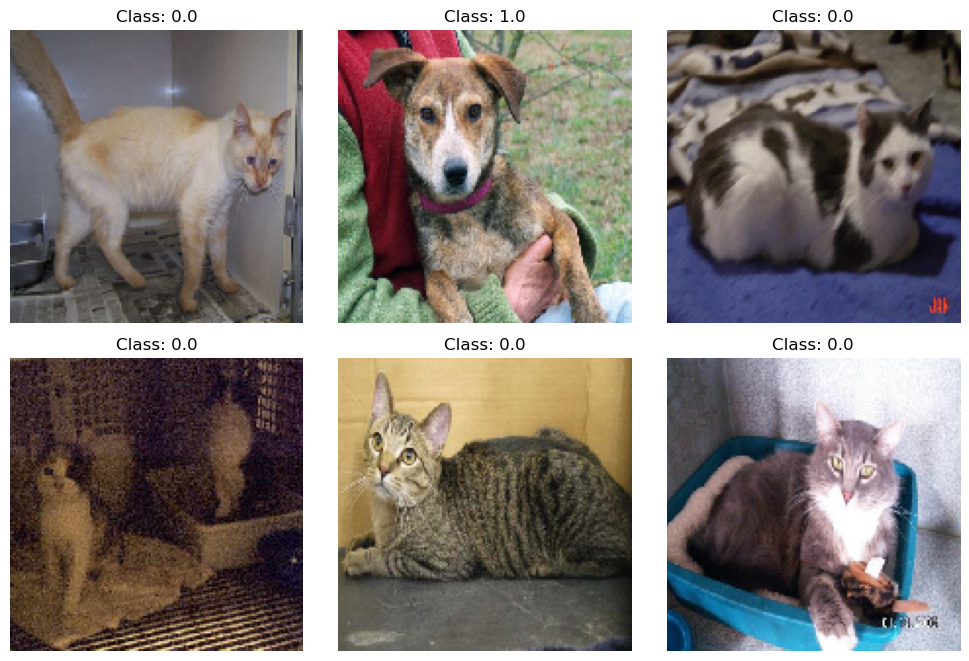

In [87]:
plot_data(train_generator,6)


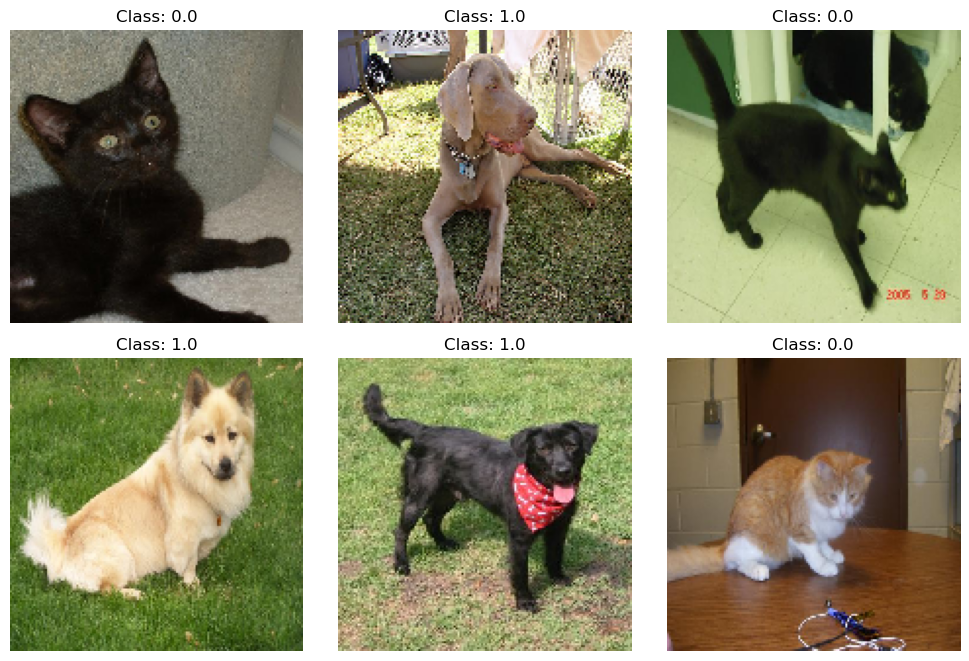

In [88]:
plot_data(validation_generator,6)


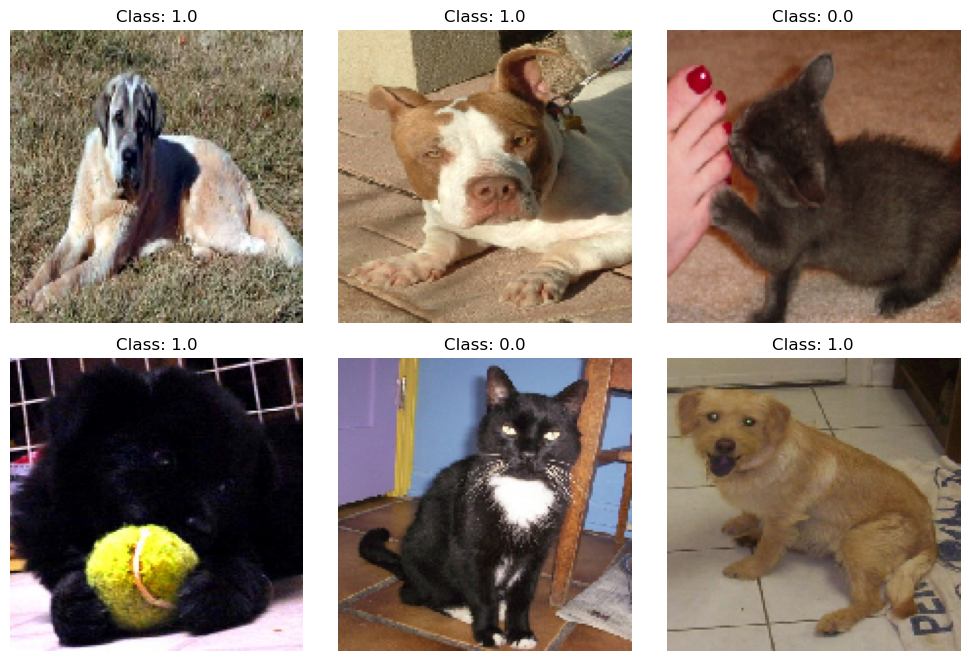

In [89]:
if INCLUDE_TEST:
    plot_data(test_generator, 6)

**Great, now that the data is ready let's train our model**

<a id="3"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Model</center></h1>
    
# Model


In [90]:
inputs = Input(shape=(150, 150, 3), name='input_image')

# 1 blokas – pradiniai filtrai
x = Conv2D(32, (3, 3), activation='relu', padding='valid', name='conv1_32')(inputs)
x = Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv2_64')(x)
x = MaxPooling2D(2, 2, name='pool1')(x)

# 2 blokas – viduriniai filtrai
x = Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv3_64')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='valid', name='conv4_128')(x)
x = MaxPooling2D(2, 2, name='pool2')(x)

# 3 blokas – gilesni filtrai
x = Conv2D(128, (3, 3), activation='relu', padding='valid', name='conv5_128')(x)
x = Conv2D(256, (3, 3), activation='relu', padding='valid', name='conv6_256')(x)

# Global pooling ir klasifikatorius
x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = Dense(220, activation='relu', name='dense_hidden')(x)
outputs = Dense(2, activation='softmax', name='output_logits')(x)

# Sukuriame modelį
model = Model(inputs=inputs, outputs=outputs, name='Classifier_v1')


In [91]:
model.summary()

Model: "Classifier_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_32 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_64 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_64 (Conv2D)               │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_128 (Conv2D)              │ (None, 69, 69, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5_128 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6_256 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 220)            │        56,540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_logits (Dense)           │ (None, 2)              │           442 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,910 (2.40 MB)

 Trainable params: 629,910 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [92]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [93]:
checkpoint_cb1 = tf.keras.callbacks.ModelCheckpoint("model_out/my_keras_model1.h5", monitor='val_accuracy',
                             mode='max',
                             save_best_only=True,
                             verbose=1)

In [94]:

r = model.fit(
        train_generator,
        epochs=10,#Training longer could yield better results
        validation_data=validation_generator, callbacks=[checkpoint_cb1])

Epoch 1/10
   5/1548 ━━━━━━━━━━━━━━━━━━━━ 1:14 49ms/step - accuracy: 0.6104 - loss: 0.6931  

/opt/conda/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5268 - loss: 0.6895  
Epoch 1: val_accuracy improved from None to 0.64578, saving model to model_out/my_keras_model1.h5



Epoch 1: finished saving model to model_out/my_keras_model1.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.5641 - loss: 0.6776 - val_accuracy: 0.6458 - val_loss: 0.6346
Epoch 2/10
1547/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6351 - loss: 0.6413  
Epoch 2: val_accuracy improved from 0.64578 to 0.71704, saving model to model_out/my_keras_model1.h5



Epoch 2: finished saving model to model_out/my_keras_model1.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.6518 - loss: 0.6280 - val_accuracy: 0.7170 - val_loss: 0.5658
Epoch 3/10
1547/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6976 - loss: 0.5911  
Epoch 3: val_accuracy did not improve from 0.71704
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.7031 - loss: 0.5790 - val_accuracy: 0.6892 - val_loss: 0.5916
Epoch 4/10
1547/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7275 - loss: 0.5484  
Epoch 4: val_accuracy improved from 0.71704 to 0.77232, saving model to model_out/my_keras_model1.h5



Epoch 4: finished saving model to model_out/my_keras_model1.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - accuracy: 0.7339 - loss: 0.5426 - val_accuracy: 0.7723 - val_loss: 0.5054
Epoch 5/10
1547/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7599 - loss: 0.5038  
Epoch 5: val_accuracy improved from 0.77232 to 0.77600, saving model to model_out/my_keras_model1.h5



Epoch 5: finished saving model to model_out/my_keras_model1.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.7654 - loss: 0.4988 - val_accuracy: 0.7760 - val_loss: 0.4751
Epoch 6/10
1547/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7985 - loss: 0.4547  
Epoch 6: val_accuracy improved from 0.77600 to 0.83907, saving model to model_out/my_keras_model1.h5



Epoch 6: finished saving model to model_out/my_keras_model1.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.8001 - loss: 0.4500 - val_accuracy: 0.8391 - val_loss: 0.3857
Epoch 7/10
1547/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8264 - loss: 0.3934  
Epoch 7: val_accuracy did not improve from 0.83907
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 75s 49ms/step - accuracy: 0.8282 - loss: 0.3954 - val_accuracy: 0.8354 - val_loss: 0.3754
Epoch 8/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8524 - loss: 0.3540  
Epoch 8: val_accuracy improved from 0.83907 to 0.87879, saving model to model_out/my_keras_model1.h5



Epoch 8: finished saving model to model_out/my_keras_model1.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.8554 - loss: 0.3479 - val_accuracy: 0.8788 - val_loss: 0.2984
Epoch 9/10
1547/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8726 - loss: 0.3246  
Epoch 9: val_accuracy did not improve from 0.87879
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.8764 - loss: 0.3145 - val_accuracy: 0.8587 - val_loss: 0.3650
Epoch 10/10
1547/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8858 - loss: 0.2875  
Epoch 10: val_accuracy improved from 0.87879 to 0.91073, saving model to model_out/my_keras_model1.h5



Epoch 10: finished saving model to model_out/my_keras_model1.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.8848 - loss: 0.2914 - val_accuracy: 0.9107 - val_loss: 0.2237


In [95]:
# Calling `save('my_model.keras')` creates a zip archive `my_model.keras`.
model.save("model_out/cat_vs_dog_model.keras")

# It can be used to reconstruct the model identically.
model = tf.keras.models.load_model("model_out/my_keras_model1.h5")

<a id="4"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Evaluation</center></h1>
    
# Evaluation


<a name="4-1"></a>

## Evaluate the model on the test set

In [96]:
if INCLUDE_TEST:
    model.evaluate(test_generator)

153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9128 - loss: 0.2174


<a name="4-2"></a>

## Visualize the predicitons

In [97]:

def plot_prediction(generator, n_images):
    """
    Test the model on random predictions
    Args:
        generator: a generator instance
        n_images : number of images to plot
    """
    i = 1
    
    # Pagrindinis pataisymas: next(generator) vietoje generator.next()
    images, labels = next(generator)
    
    # Modelio prognozės
    preds = model.predict(images)
    predictions = np.argmax(preds, axis=1)
    labels = labels.astype('int32')
    
    plt.figure(figsize=(10, 10))
    
    for image, label in zip(images, labels):
        plt.subplot(4, 3, i)  # jei nori 4 eilutės × 3 stulpeliai
        plt.imshow(image)
        
        if predictions[i-1] == label:  # i pradeda nuo 1, tad predictions indeksas i-1
            title_obj = plt.title(class_names[label])
            plt.setp(title_obj, color='g')
        else:
            title_obj = plt.title(f"{class_names[label]} (pred: {class_names[predictions[i-1]]})")
            plt.setp(title_obj, color='r')
            
        plt.axis('off')
        i += 1
        
        if i > n_images:
            break
   
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


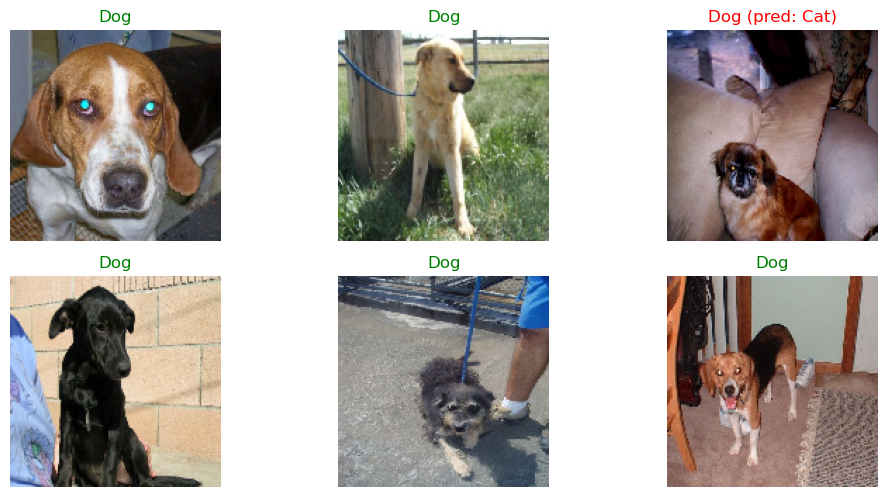

In [98]:
if INCLUDE_TEST:
    plot_prediction(test_generator, 6)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


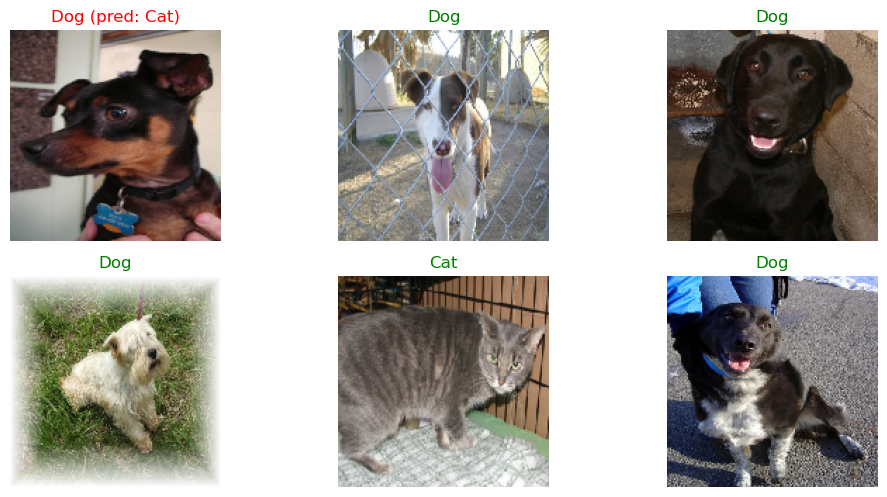

In [99]:
plot_prediction(validation_generator, 6)

<a name="4-3"></a>

## Visualize class activation maps

In [100]:
# Create a  model to visualize activation maps
gp_weights =  model.get_layer('dense_hidden').get_weights()[0]
activation_model = Model(model.inputs, outputs=(model.get_layer('conv6_256').output, model.get_layer('output_logits').output))

In [101]:
# Use the model to make predictions on the test generator
images, _ = next(test_generator)
features, results = activation_model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


In [102]:
results

array([[2.9427740e-01, 7.0572263e-01],
       [7.6625502e-01, 2.3374501e-01],
       [9.1420878e-03, 9.9085790e-01],
       [9.9711007e-01, 2.8899414e-03],
       [1.0001238e-06, 9.9999905e-01],
       [2.7393025e-01, 7.2606969e-01],
       [9.8000491e-01, 1.9995036e-02],
       [6.4012061e-13, 1.0000000e+00],
       [6.6979772e-01, 3.3020228e-01],
       [7.5186384e-01, 2.4813618e-01],
       [1.0000000e+00, 3.3567157e-10],
       [1.5984137e-04, 9.9984014e-01],
       [4.3340701e-01, 5.6659305e-01],
       [2.7762088e-01, 7.2237903e-01],
       [2.3811524e-06, 9.9999762e-01],
       [1.5049959e-05, 9.9998498e-01]], dtype=float32)

In [103]:
def show_cam(image_index, features, results):
    """
    Shows activation maps
    Args:
    image_index: index of image
    features: the extracted features
    results: model's predictions
    """
    # takes the features of the chosen image
    features_for_img = features[image_index,:,:,:]

    # get the class with the highest output probability
    prediction = np.argmax(results[image_index])

    # get the gap weights at the predicted class
    class_activation_weights = gp_weights[:,prediction]

    # upsample the features to the image's original size (150 x 150)
    class_activation_features = sp.ndimage.zoom(features_for_img, (150/30, 150/30, 1), order=2)

    # compute the intensity of each feature in the CAM
    cam_output  = np.dot(class_activation_features,class_activation_weights)

    print('Predicted Class = ' +str(class_names[prediction])+ ', Probability = ' + str(results[image_index][prediction]))

    # show the upsampled image
    
    plt.imshow(images[image_index])

    # strongly classified (95% probability) images will be in green, else red
    if results[image_index][prediction]>0.95:
        cmap_str = 'Greens'
    else:
        cmap_str = 'Blues'

    # overlay the cam output
    plt.imshow(cam_output, cmap=cmap_str, alpha=0.5)

    # display the image
    plt.show()

In [104]:
def show_maps(desired_class, num_maps):
    '''
    goes through the first 10,000 test images and generates Cam activation maps
    Args:
    desired_class: class to show the maps for
    num_maps: number of maps to be generated 
    '''
    counter = 0
    # go through the first 10000 images
    for i in range(0,10000):
        # break if we already displayed the specified number of maps
        if counter == num_maps:
            break

        # images that match the class will be shown
        if np.argmax(results[i]) == desired_class:
            counter += 1
            show_cam(i,features, results)

Predicted Class = Dog, Probability = 0.70572263


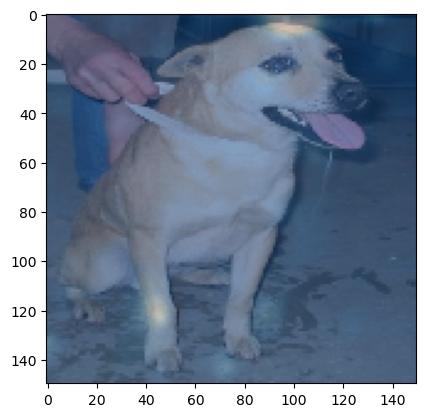

Predicted Class = Dog, Probability = 0.9908579


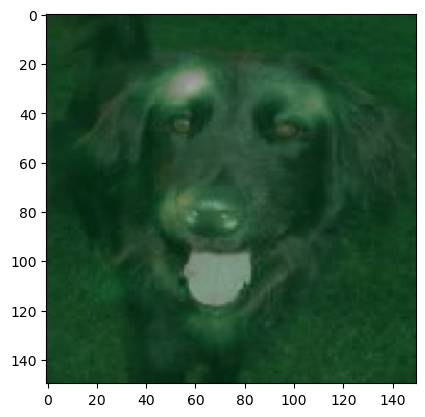

Predicted Class = Dog, Probability = 0.99999905


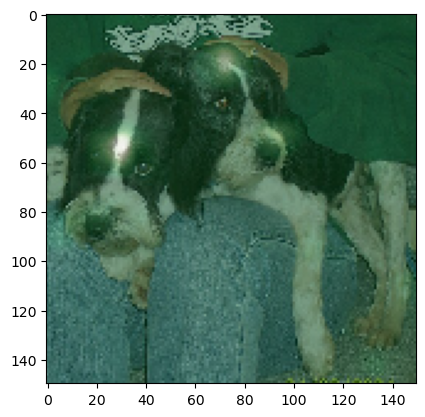

Predicted Class = Dog, Probability = 0.7260697


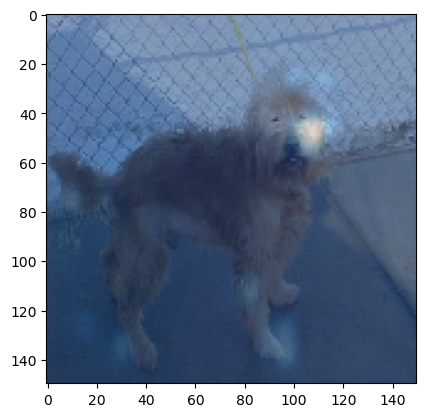

Predicted Class = Dog, Probability = 1.0


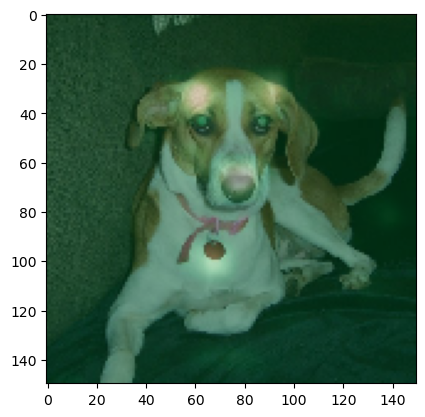

In [105]:
show_maps(desired_class=1, num_maps=5)

Predicted Class = Cat, Probability = 0.766255


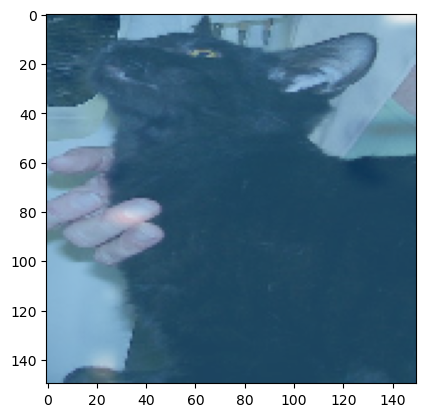

Predicted Class = Cat, Probability = 0.99711007


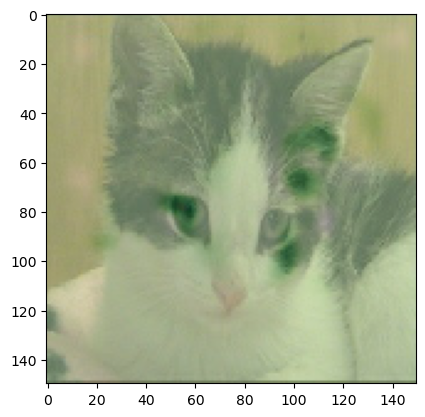

Predicted Class = Cat, Probability = 0.9800049


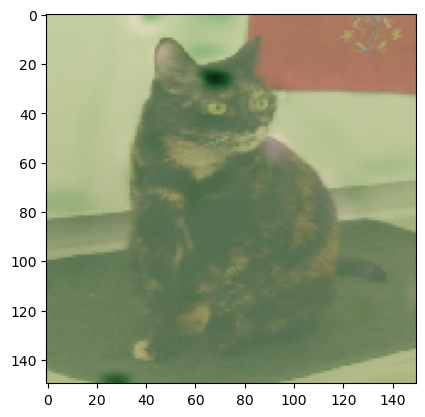

Predicted Class = Cat, Probability = 0.6697977


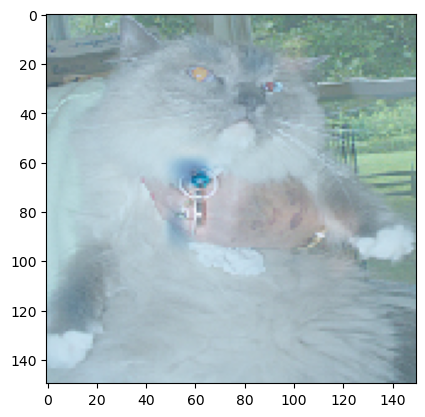

Predicted Class = Cat, Probability = 0.75186384


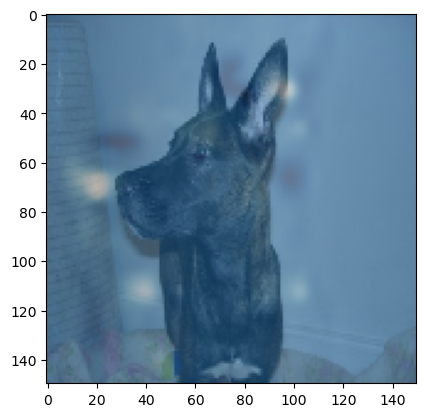

In [106]:
show_maps(desired_class=0, num_maps=5)

<a name="4-4"></a>

## Visualize training process

In [107]:
results = pd.DataFrame(r.history)
results.tail()

,accuracy,loss,val_accuracy,val_loss
5,0.800145,0.449965,0.839066,0.385687
6,0.828217,0.395383,0.835381,0.375424
7,0.855441,0.347878,0.878788,0.298413
8,0.876404,0.314504,0.858722,0.365019
9,0.884845,0.291418,0.910729,0.223695


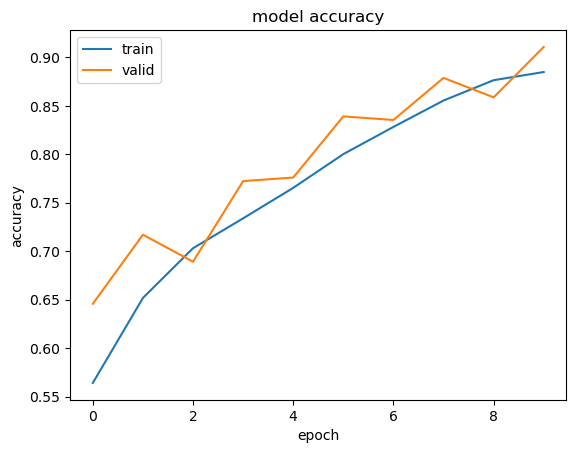

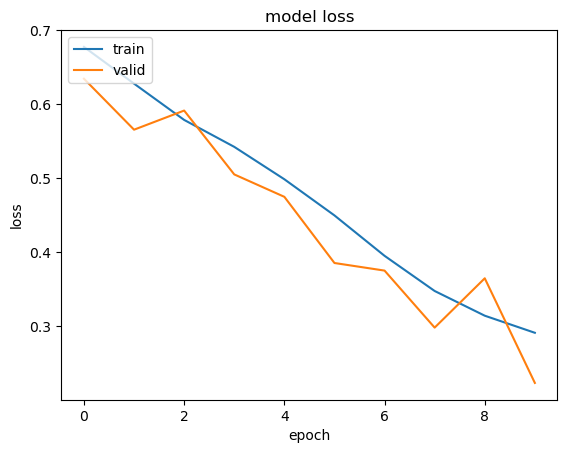

In [108]:
# summarize history for accuracy
plt.plot(results['accuracy'])
plt.plot(results['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(results['loss'])
plt.plot(results['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper left')
plt.show()



**Let's try using data augmentation**

<a id="5"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Trying Data Augmentation </center></h1>

# Trying Data Augmentation 

In [109]:
train_gen_aug = ImageDataGenerator(
        rescale=1./255,fill_mode='nearest',
    horizontal_flip=True,
        rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
)


validation_gen_aug =  ImageDataGenerator(
        rescale=1./255.)


In [110]:
train_generator = train_gen_aug.flow_from_directory(
        '/tmp/cats-v-dogs/training',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')
validation_generator = validation_gen_aug.flow_from_directory(
        '/tmp/cats-v-dogs/validation',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')

Found 24758 images belonging to 2 classes.
Found 2442 images belonging to 2 classes.


In [111]:
inputs = tf.keras.layers.Input(shape=(150,150,3))
x =  tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(220, activation='relu')(x) 
x = tf.keras.layers.Dense(2, activation='softmax')(x) 

model_aug = Model(inputs=inputs, outputs=x)

In [112]:
model_aug.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 69, 69, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 220)            │        56,540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           442 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,910 (2.40 MB)

 Trainable params: 629,910 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [113]:
model_aug.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [114]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model_out/my_keras_model.h5", monitor='val_accuracy',
                             mode='max',
                             save_best_only=True,
                             verbose=1)

In [115]:
r = model_aug.fit(
        train_generator,
        epochs=10,#Training longer could yield better results
        validation_data=validation_generator, callbacks=[checkpoint_cb])

Epoch 1/10
1483/1548 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.5090 - loss: 0.6961  

/opt/conda/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5098 - loss: 0.6959
Epoch 1: val_accuracy improved from None to 0.59500, saving model to model_out/my_keras_model.h5



Epoch 1: finished saving model to model_out/my_keras_model.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 123s 79ms/step - accuracy: 0.5286 - loss: 0.6912 - val_accuracy: 0.5950 - val_loss: 0.6800
Epoch 2/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5963 - loss: 0.6688  
Epoch 2: val_accuracy improved from 0.59500 to 0.63227, saving model to model_out/my_keras_model.h5



Epoch 2: finished saving model to model_out/my_keras_model.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 124s 80ms/step - accuracy: 0.6118 - loss: 0.6591 - val_accuracy: 0.6323 - val_loss: 0.6372
Epoch 3/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6502 - loss: 0.6301  
Epoch 3: val_accuracy improved from 0.63227 to 0.69943, saving model to model_out/my_keras_model.h5



Epoch 3: finished saving model to model_out/my_keras_model.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 123s 79ms/step - accuracy: 0.6593 - loss: 0.6225 - val_accuracy: 0.6994 - val_loss: 0.6003
Epoch 4/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6806 - loss: 0.6060  
Epoch 4: val_accuracy improved from 0.69943 to 0.73423, saving model to model_out/my_keras_model.h5



Epoch 4: finished saving model to model_out/my_keras_model.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 124s 80ms/step - accuracy: 0.6849 - loss: 0.6021 - val_accuracy: 0.7342 - val_loss: 0.5431
Epoch 5/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7075 - loss: 0.5840  
Epoch 5: val_accuracy did not improve from 0.73423
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 124s 80ms/step - accuracy: 0.7085 - loss: 0.5790 - val_accuracy: 0.7105 - val_loss: 0.5573
Epoch 6/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7253 - loss: 0.5606  
Epoch 6: val_accuracy improved from 0.73423 to 0.77273, saving model to model_out/my_keras_model.h5



Epoch 6: finished saving model to model_out/my_keras_model.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 125s 80ms/step - accuracy: 0.7295 - loss: 0.5554 - val_accuracy: 0.7727 - val_loss: 0.4994
Epoch 7/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7438 - loss: 0.5349  
Epoch 7: val_accuracy did not improve from 0.77273
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 124s 80ms/step - accuracy: 0.7476 - loss: 0.5299 - val_accuracy: 0.7432 - val_loss: 0.5273
Epoch 8/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7684 - loss: 0.4982  
Epoch 8: val_accuracy improved from 0.77273 to 0.78583, saving model to model_out/my_keras_model.h5



Epoch 8: finished saving model to model_out/my_keras_model.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 124s 80ms/step - accuracy: 0.7733 - loss: 0.4930 - val_accuracy: 0.7858 - val_loss: 0.4723
Epoch 9/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7827 - loss: 0.4726  
Epoch 9: val_accuracy did not improve from 0.78583
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 123s 79ms/step - accuracy: 0.7861 - loss: 0.4709 - val_accuracy: 0.7690 - val_loss: 0.5082
Epoch 10/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8026 - loss: 0.4462  
Epoch 10: val_accuracy improved from 0.78583 to 0.86446, saving model to model_out/my_keras_model.h5



Epoch 10: finished saving model to model_out/my_keras_model.h5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 125s 81ms/step - accuracy: 0.8082 - loss: 0.4377 - val_accuracy: 0.8645 - val_loss: 0.3811


In [116]:
# Calling `save('my_model.keras')` creates a zip archive `my_model.keras`.
model_aug.save("model_out/cat_vs_dog_model_aug.keras")
model_aug_2 = tf.keras.models.load_model("model_out/my_keras_model.h5")
# It can be used to reconstruct the model identically.
#model_aug = keras.models.load_model("my_model.keras")

In [117]:
results = pd.DataFrame(r.history)
results.tail()

,accuracy,loss,val_accuracy,val_loss
5,0.729502,0.555396,0.772727,0.499425
6,0.747556,0.529853,0.743243,0.527343
7,0.773285,0.492979,0.785831,0.472264
8,0.786089,0.470866,0.769042,0.508152
9,0.808183,0.437738,0.864455,0.381067


In [118]:
results

,accuracy,loss,val_accuracy,val_loss
0,0.528597,0.691175,0.595004,0.679987
1,0.611802,0.659132,0.632269,0.637155
2,0.659302,0.622453,0.699427,0.600258
3,0.684870,0.602144,0.734234,0.543130
4,0.708498,0.579023,0.710483,0.557265
5,0.729502,0.555396,0.772727,0.499425
6,0.747556,0.529853,0.743243,0.527343
7,0.773285,0.492979,0.785831,0.472264
8,0.786089,0.470866,0.769042,0.508152
9,0.808183,0.437738,0.864455,0.381067


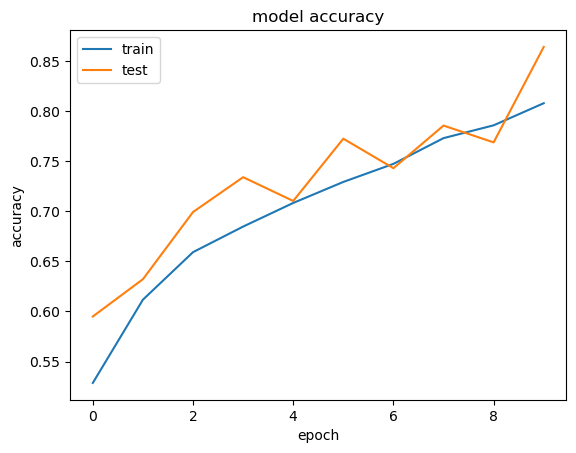

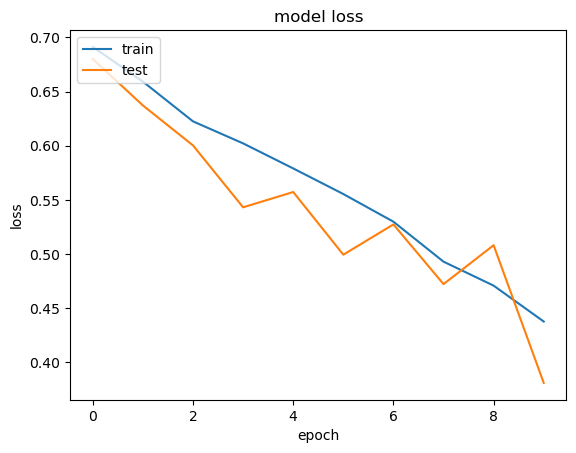

In [119]:
# summarize history for accuracy
plt.plot(results['accuracy'])
plt.plot(results['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(results['loss'])
plt.plot(results['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Evaluate augmentation model

In [120]:
if INCLUDE_TEST:
    model_aug.evaluate(test_generator)

153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8554 - loss: 0.3706


In [121]:
if INCLUDE_TEST:
    model_aug_2.evaluate(test_generator)

153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8554 - loss: 0.3706


<a id="5"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Cat vs Dog Classifier Using Transfer Learning Xception PreTrained Mode </center></h1>
 

![](https://miro.medium.com/v2/resize:fit:640/format:webp/1*459jKxLPM9R-Y_z0y8SXug.png)

![](https://miro.medium.com/v2/resize:fit:786/format:webp/1*tCTo6M1E5rZ4_ARnPcv-gQ.png)

In [122]:
#PreTrained Model VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import Xception
from keras import Sequential
from keras import layers

class CustomMaskLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(CustomMaskLayer, self).__init__(**kwargs)
        # Inicializuok savo sluoksnio parametrus čia

    def call(self, inputs):
        # Tavo sluoksnio logika čia
        return inputs

    def get_config(self):
        # Grąžink visus parametrus, kuriuos reikia išsaugoti ir vėl užkrauti
        config = super(CustomMaskLayer, self).get_config()
        return config

In [123]:
train_generator = train_gen_aug.flow_from_directory(
        '/tmp/cats-v-dogs/training',
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')
validation_generator = validation_gen_aug.flow_from_directory(
        '/tmp/cats-v-dogs/validation',
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')
test_generator = test_gen.flow_from_directory(
        '/tmp/cats-v-dogs/test',
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')

Found 24758 images belonging to 2 classes.
Found 2442 images belonging to 2 classes.
Found 2442 images belonging to 2 classes.


In [124]:
# Load the pre-trained Xception model without the top (classification) layer
xception_base = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
xception_base.trainable = False

In [125]:
# Build the model
model_x = Sequential()

# Add the pre-trained Xception base
model_x.add(xception_base)

# Add global average pooling layer to reduce spatial dimensions
model_x.add(AveragePooling2D(pool_size=(2, 2)))

# Flatten the feature maps
model_x.add(Flatten())

# Add a dense layer with 220 units and ReLU activation function
model_x.add(Dense(220, activation='relu'))

# Add the output layer with 2 unit and sigmoid activation function for binary classification
model_x.add(Dense(2, activation='sigmoid'))

In [126]:
#Complie
model_x.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.0001, rho=0.9),
                loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [127]:
r = model_x.fit(
        train_generator,
        epochs=2,
        validation_data=validation_generator)

Epoch 1/2
649/774 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.9282 - loss: 0.1833 

/opt/conda/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


774/774 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9307 - loss: 0.1769 

KeyboardInterrupt: 

In [ ]:
# Calling `save('my_model.keras')` creates a zip archive `my_model.keras`.
#model_x.save("cat_vs_dog_model_x.keras")
#model_x2 = tf.keras.models.load_model("/kaggle/working/my_x_keras_model.h5", custom_objects={'CustomMaskLayer': CustomMaskLayer, 'Xception': xception_base}, , compile=False)
# It can be used to reconstruct the model identically.


In [ ]:
if INCLUDE_TEST:
    model_x.evaluate(test_generator)

In [ ]:
from skimage import io
import cv2
#image = io.imread('https://www.vle.lt/uploads/_CGSmartImage/114292_1-1608eda0d9c54043ad61ed96f6239ef6.jpg')
image = io.imread('https://s1.15min.lt/static/cache/OTcweDU4MCwzODJ4NDg3LDcxNTcyOCxvcmlnaW5hbCwsaWQ9MzExODMwOCZkYXRlPTIwMTclMkYwNiUyRjA5LDM2MjEwNTE5ODM=/juoda-veido-kauke-593a88d641962.jpg')
img = cv2.resize(image, (150, 150))
    # Normalize pixel values
img_array = img.astype(np.float32) / 255.0  

    # Expand the dimensions to match the input shape expected by the model
img_array = np.expand_dims(img_array, axis=0)

    # Make predictions
predictions = model_x.predict(img_array)

In [ ]:
predictions[0][1]

In [ ]:
    actual_prediction = (predictions[0][0] > predictions[0][1]).astype(int)

    # Display the image with true and predicted labels
    # Convert BGR to RGB for displaying with matplotlib
    plt.imshow(img)  
    plt.axis('off')
    if actual_prediction == 1:
        predicted_label = 'Cat'
    else:
        predicted_label = 'Dog'
    plt.title(f'Predicted: {predicted_label} ')
    plt.show()

<a id="5"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Conclusion </center></h1>

# Conclusion 

**Using data augmentation with these hyper-parameters gave us worse results**


**We can Use [transfer learning](https://www.kaggle.com/code/fareselmenshawii/introdution-to-transfer-learning/edit/run/109466477) or a more complex architecture to solve this problem**

**We'll discuss these topics in later notebooks**

<a id="7"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Thank You </center></h1>


    
# Thank You

**Thank you for taking your time and going through this notebook**

**Please let me know if you have any feedback**